# Module 3a: Dimension Reduction using Feature Selection
Zhengqing Hu, PSUPR <br><br>
**1. Filter Method:** a.Correlation, b.Anova <br>
**2. Wrapper Method:** c.Forward Feature Selection, d.Backward Feature Elimination, e.Recursive Feature Elimination <br>
**3. Embedded Methods:** f.Random Forest Classifier <br>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import set_printoptions
# Select features according to the k highest scores
from sklearn.feature_selection import SelectKBest 
import warnings
warnings.filterwarnings('ignore')

In [3]:
#Load the dataset
data = pd.read_csv('Cancer.csv')
data = data.drop(columns=['id','Unnamed: 32'])

print(data.shape)
print(data.isnull().values.any()) # check for any missing values
data.diagnosis.value_counts() # show the distribution of M/B

(569, 31)
False


diagnosis
B    357
M    212
Name: count, dtype: int64

In [5]:
from sklearn.model_selection import train_test_split

target = 'diagnosis'
X = data.loc[:, data.columns != target]
Y = data.loc[:, data.columns == target]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=52)
features = pd.DataFrame(list(X_train.columns.values))

In [6]:
# Establish a baseline for comparison using LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(C=0.01)
lr = logreg.fit(X_train, y_train)
print("LogReg Training set score:",lr.score(X_train, y_train))
print("       Test set score    :",lr.score(X_test, y_test))

LogReg Training set score: 0.9221105527638191
       Test set score    : 0.9473684210526315


# 1. Filter Methods

## (a) Correlation Analysis

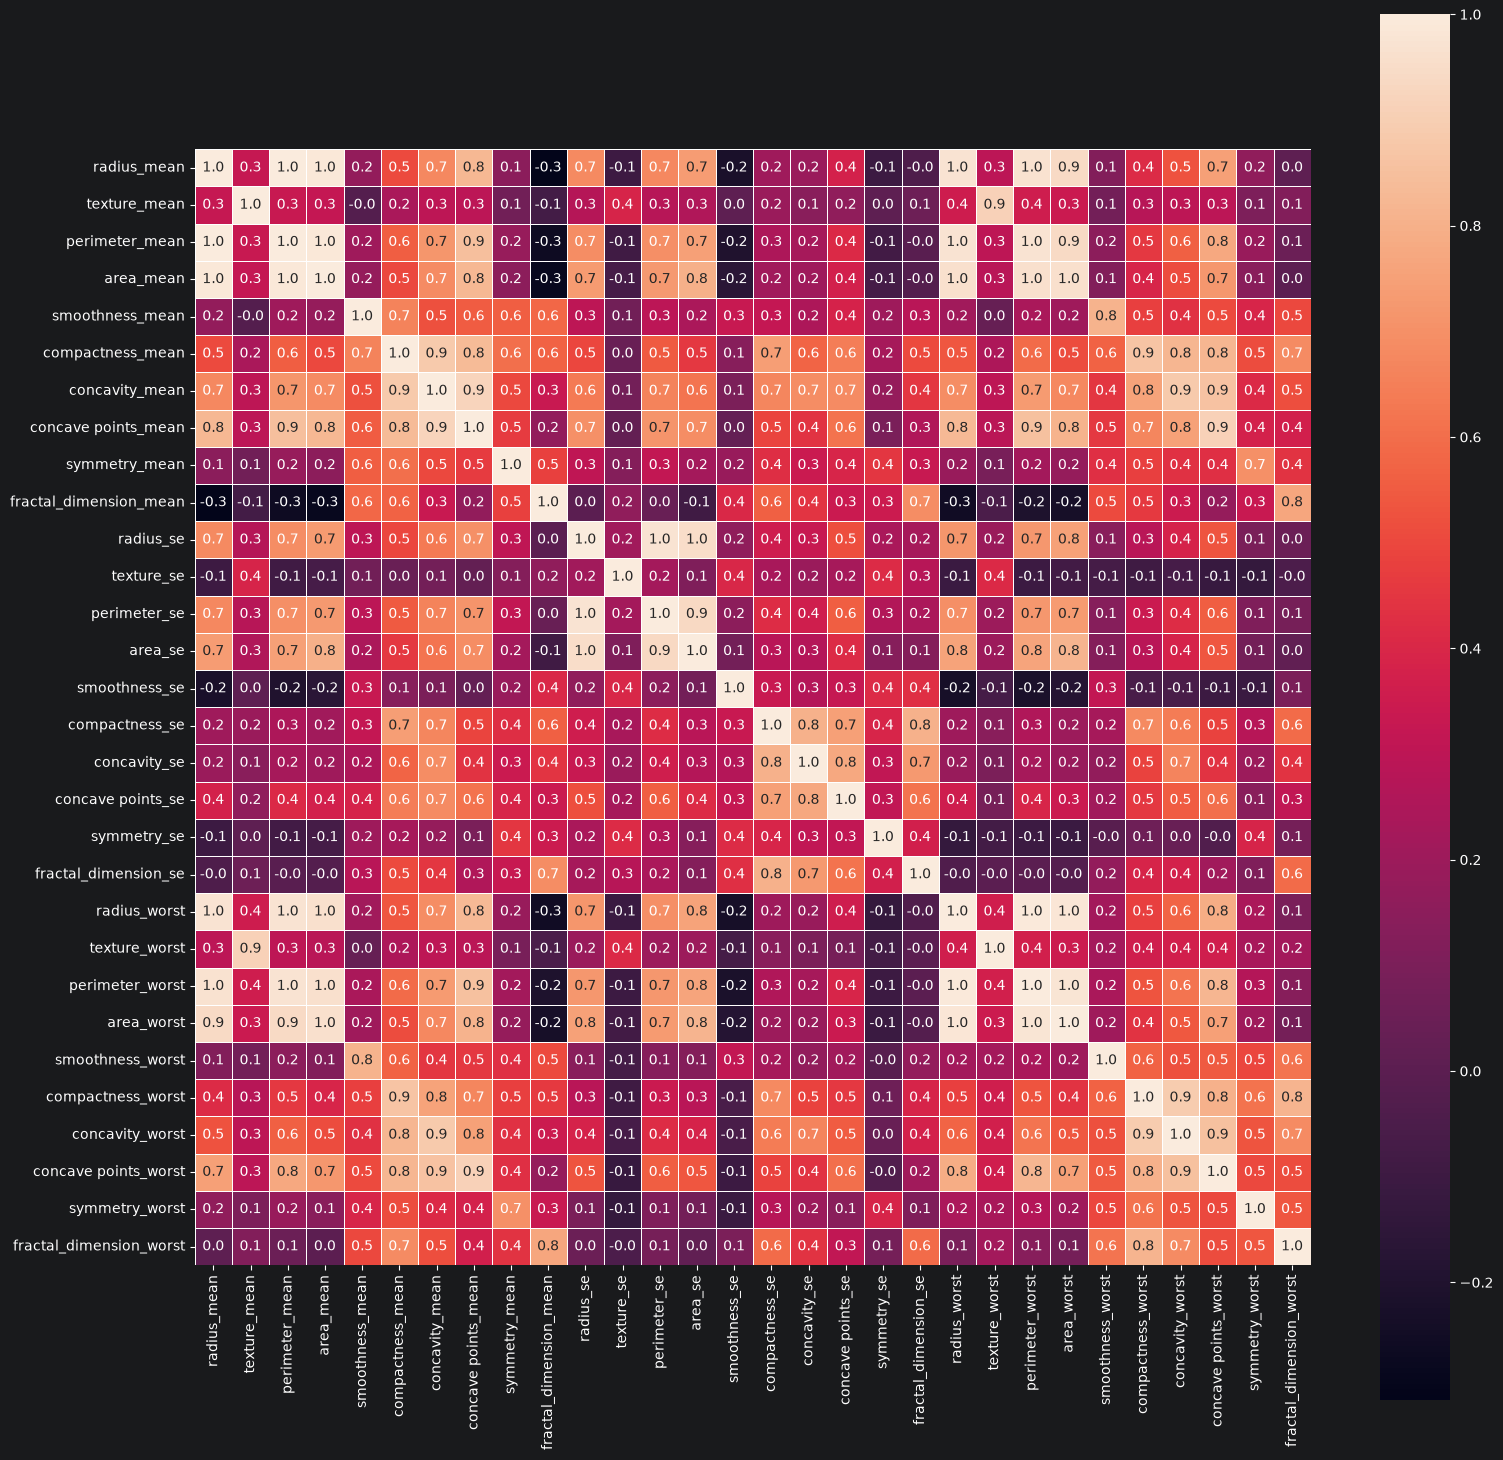

In [7]:
f = plt.figure(figsize=(18, 18))
ax = plt.subplot(aspect='equal')
corplot = sns.heatmap(X.corr(), annot=True, linewidths=.5, fmt= '.1f',ax=ax)

# correlation >= 0.9
# 1)radius_mean: perimeter_mean, area_mean, radius_worst, perimeter_worst, area_worst 
# 2)texture_mean: texture_worst, Compactness_worst
# 3)Compactness_mean: concavity_mean
# 4)concave points_mean: concave points_worst
# 5)radius_se: perimeter_se, area_se
# 6)concavity_se: Compactness_se, concave points_se 

In [8]:
# Remove Corelated Features (>0.90) - requires domain expertise!
# you can try other different combinations

deselect = ['perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean', 'perimeter_se', 
            'area_se', 'concavity_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 
            'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 
            'concave points_worst', 'fractal_dimension_worst']
len(deselect)

17

<div class="alert-danger">
    
**TASK#1:**
    
 - write code to automatically extract out the features pairs with r>0.9
 - Using domain knowledge or randomly remove one of the correlated pair
 - Use this reduced feature set to run prediction
 - Did you observe any difference in the performance?

</div>


In [9]:
# test Logreg model with the reduced set of features
X_train_new = X_train.drop(deselect,axis = 1)
X_test_new = X_test.drop(deselect,axis = 1) 
print(X_train_new.shape)

lr = logreg.fit(X_train_new, y_train)
print("Corr Training set score:",lr.score(X_train_new, y_train))
print("     Test set score    :",lr.score(X_test_new, y_test))

(398, 13)
Corr Training set score: 0.8894472361809045
     Test set score    : 0.8947368421052632


How is the model performance compared with baseline LogReg?

## (b) Anova (f_classif)

<div class="alert-danger">
    
**TASK#2** 
 - Set the number of features you want to select as imput for predictive modeling
 - Run the Anova and Wrapper methods to select (f) features and check on the model performance
 - Experiment with values of f
 - Do you observe any peformance difference among the different features selection methods?

</div>

In [10]:
f = len(features)-len(deselect) # number of reduced features to use

In [11]:
from sklearn.feature_selection import f_classif

Anova = SelectKBest(score_func=f_classif, k=f).fit(X_train, y_train)
AnovaRanking = pd.DataFrame({'Feature':list(X_train.columns),'Scores':Anova.scores_})
AnovaRanking.sort_values(by='Scores', ascending=False, inplace=True)

print('Top', f, 'selected:')
display(AnovaRanking.head(f))

Top 13 selected:


,Feature,Scores
27,concave points_worst,676.716398
7,concave points_mean,630.854979
22,perimeter_worst,595.995645
20,radius_worst,559.930079
2,perimeter_mean,462.976937
23,area_worst,458.134934
0,radius_mean,419.834601
3,area_mean,409.643914
6,concavity_mean,407.978442
26,concavity_worst,302.023031


#### Use Anova Selected Features on logreg model

In [12]:
X_train_new = Anova.transform(X_train) 
X_test_new = Anova.transform(X_test)

lr = logreg.fit(X_train_new, y_train)
print("Anova Training set score:",lr.score(X_train_new, y_train))
print("      Test set score    :",lr.score(X_test_new, y_test))
print('\nHow is the model performance compared with the original LogReg?')

Anova Training set score: 0.9371859296482412
      Test set score    : 0.9532163742690059

How is the model performance compared with the original LogReg?


# 2. Wrapper Methods

In [13]:
from sklearn.feature_selection import SequentialFeatureSelector as SFS
from sklearn.svm import LinearSVC
# I am using the Linear Support Vector Classifier algoritm 
# Others are SVC(other kernels), OLS, Linear/Log Regression, Decision Trees, etc.

<div class="alert-danger">

**TASK#3** 

 - Try different algorithms as wrappers
     - from sklearn.tree import DecisionTreeClassifier
     - from sklearn.linear_model import LogisticRegression
     - from sklearn.svm import SVC
 - What do you observe with the use of different **wrapper** algorithms?

</div>

## (c) Forward Feature Selection (FFS)

In [16]:
# note that you could perform a Hyperparameter estimation for C

model = LinearSVC(C=0.5, random_state = 42) # higher values tend to overfit
model.fit(X_train, y_train)

sfs = SFS(estimator=model, n_features_to_select=f, direction='forward').fit(X_train, y_train)
print('FFS:'f'{features[sfs.get_support()]}')
print('\nCompare the selected features here with the ealier methods.\n')

FFS:                       0
0            radius_mean
1           texture_mean
2         perimeter_mean
4        smoothness_mean
5       compactness_mean
6         concavity_mean
7    concave points_mean
8          symmetry_mean
20          radius_worst
22       perimeter_worst
23            area_worst
25     compactness_worst
27  concave points_worst

Compare the selected features here with the ealier methods.



In [17]:
#sfs.transform(X): Reduce X to the FFS selected features.
X_train_new = sfs.transform(X_train)
X_test_new = sfs.transform(X_test)

# Run the baseline Logreg model with the SFS reduced dataset
lr = logreg.fit(X_train_new, y_train)
print('Forward Feature Selection [FFS] using SVC\n')
print('Test models with FFS Reduced Features::\n')
print('  LogReg Train:', lr.score(X_train_new, y_train))
print('  LogReg Test :', lr.score(X_test_new, y_test))
print('  *** Compare this result with the baseline Logreg\n')

# Run SVC Model using the FFS Reduced Features
# note that we cannot set random state - so every run will be different
sfs_test = model.fit(X_train_new, y_train)
print('  SVC Train:',sfs_test.score(X_train_new, y_train))
print('  SVC Test :',sfs_test.score(X_test_new, y_test))
print('  *** Compare this result with the previous models\n')

Forward Feature Selection [FFS] using SVC

Test models with FFS Reduced Features::

  LogReg Train: 0.9246231155778895
  LogReg Test : 0.9766081871345029
  *** Compare this result with the baseline Logreg

  SVC Train: 0.9597989949748744
  SVC Test : 0.9649122807017544
  *** Compare this result with the previous models



## (d) Backward Feature Elimination (BFE)

In [18]:
sfs = SFS(model, n_features_to_select=f, direction='backward').fit(X_train, y_train)
print('BFE:'f'{features[sfs.get_support()]}')
print('\nCompare the selected features here with the ealier methods.\n')

BFE:                       0
0            radius_mean
3              area_mean
5       compactness_mean
11            texture_se
13               area_se
20          radius_worst
21         texture_worst
22       perimeter_worst
23            area_worst
24      smoothness_worst
25     compactness_worst
27  concave points_worst
28        symmetry_worst

Compare the selected features here with the ealier methods.



In [19]:
X_train_new = sfs.transform(X_train)
X_test_new = sfs.transform(X_test)

# Run the baseline Logreg model with the SFS reduced dataset
lr = logreg.fit(X_train_new, y_train)

print('Backward Feature Elimination [BFE] using SVC\n')
print('Test models with BFE Reduced Features::\n')
print('  LogReg Train:', lr.score(X_train_new, y_train))
print('  LogReg Test :', lr.score(X_test_new, y_test))
print('  *** Compare this result with the baseline Logreg\n')

# Run LinearSVC Model using the BFE Reduced Features
sfs_test = model.fit(X_train_new, y_train)
print('  SVC Train:',sfs_test.score(X_train_new, y_train))
print('  SVC Test :',sfs_test.score(X_test_new, y_test))
print('  *** Compare this result with the previous models\n')


Backward Feature Elimination [BFE] using SVC

Test models with BFE Reduced Features::

  LogReg Train: 0.9321608040201005
  LogReg Test : 0.9473684210526315
  *** Compare this result with the baseline Logreg

  SVC Train: 0.9597989949748744
  SVC Test : 0.9590643274853801
  *** Compare this result with the previous models



## (e) Recursive Feature Elimination- RFE

https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html

In [20]:
from sklearn.feature_selection import RFE
# step: number of features to remove at each iteration
rfe = RFE(estimator=model, n_features_to_select=f, step=1).fit(X_train, y_train)

RFEfeatures = pd.DataFrame({'Feature':list(X_train.columns),'Scores':rfe.ranking_})
RFEfeatures.sort_values(by='Scores', ascending=True, inplace=True)
display(RFEfeatures.head(20))
print('\nCompare the selected features here with the ealier methods.\n')

,Feature,Scores
0,radius_mean,1
2,perimeter_mean,1
6,concavity_mean,1
5,compactness_mean,1
7,concave points_mean,1
10,radius_se,1
9,fractal_dimension_mean,1
8,symmetry_mean,1
15,compactness_se,1
26,concavity_worst,1



Compare the selected features here with the ealier methods.



In [21]:
# test the reduced dataset 
X_train_new = rfe.transform(X_train)
X_test_new = rfe.transform(X_test)

# Run the baseline Logreg model with the SFS reduced dataset
lr = logreg.fit(X_train_new, y_train)

print('Recursive Feature Elimination [RFE] using SVC\n')
print('Test models with RFE Reduced Features::\n')
print('  LogReg Train:', lr.score(X_train_new, y_train))
print('  LogReg Test :', lr.score(X_test_new, y_test))
print('  *** Compare this result with the baseline Logreg\n')

# Run LinearSVC Model using the RFE Reduced Features
sfs_test = model.fit(X_train_new, y_train)
print('  SVC Train:',sfs_test.score(X_train_new, y_train))
print('  SVC Test :',sfs_test.score(X_test_new, y_test))
print('  *** Compare this result with the previous models\n')

Recursive Feature Elimination [RFE] using SVC

Test models with RFE Reduced Features::

  LogReg Train: 0.8793969849246231
  LogReg Test : 0.9064327485380117
  *** Compare this result with the baseline Logreg

  SVC Train: 0.9195979899497487
  SVC Test : 0.9473684210526315
  *** Compare this result with the previous models



<div class="alert-danger">
    
**TASK#4** 
 - Compare and contrast the directions: Forward, Backward and Recursive
 - which direction yields the best performance?
 - Explain/justify what you think so?
</div>

# 3. Embedded Methods

## (f) Random Forest Classifier - Feature importance is part of output

In [22]:
# Run a RFC model using ALL features and let it find important features using weights
# To use RF purely for feature selection, we have to use 'SelectFromModel' (see next cell)
# However, note that SelectFromModel object has no attribute 'predict'

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.metrics import accuracy_score, recall_score

# n_estimators = number of trees to build
# oob = out-of-bag scores
rfc = RandomForestClassifier(n_estimators=500, oob_score=True, random_state=43)      
rfc = rfc.fit(X_train,y_train)

accuracy = accuracy_score(y_test, rfc.predict(X_test))
print('RandomForest:', accuracy)
print('OOB error   :', rfc.oob_score_)
final_df = pd.DataFrame({"Features": X_train.columns, "Importances":rfc.feature_importances_})
# Sklearn: "computed as the mean and standard deviation of accumulation of the impurity decrease within each tree."

final_df.set_index('Importances')
final_df.sort_values('Importances',ascending = False, inplace=True)
print('\nSet of *Ranked* important features determined by the RF algorithm')
print('\nCompare the top',f,'selected features here with the ealier methods.\n')

#display(final_df.head(10)) #note I used f=10)
display(final_df.head(f)) 

# final_df['Importances'].sum() sum of importance (weights) = 1.0
print('\nThe total importance (out of 1.0) from top 10 features:')
final_df['Importances'].head(10).sum() #sum of importance (weights)


RandomForest: 0.9766081871345029
OOB error   : 0.957286432160804

Set of *Ranked* important features determined by the RF algorithm

Compare the top 13 selected features here with the ealier methods.



,Features,Importances
27,concave points_worst,0.144156
22,perimeter_worst,0.129047
23,area_worst,0.108481
7,concave points_mean,0.100994
20,radius_worst,0.092711
6,concavity_mean,0.058696
2,perimeter_mean,0.048802
3,area_mean,0.048656
26,concavity_worst,0.038658
0,radius_mean,0.034895



The total importance (out of 1.0) from top 10 features:


np.float64(0.8050963729741497)

<div class="alert-danger">

**TASK#5** 
 - Refer to 
     - https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
 - Add parameters such as <br> n_estimators=1000, <br>criterion='gini', <br>max_depth=??, <br>min_samples_split=?, <br>min_samples_leaf=?, <br>min_weight_fraction_leaf=0.5, <br>max_features='sqrt', <br>max_leaf_nodes=10
 - Review the model performance after manually tuning the parameters
 - Or you may use GridSearchcv()


## (g) Random Forest Classifier - Using SelectFromModel to extract important features

In [23]:
# Use the RF model for Feature Selection using SelectFromModel to extract important features 
# The output feature set is consistent with the RFC model in 3(f)
# NOTE: SelectFromModel' object has no attribute 'predict'
#       There is no k - it outputs based on some internal threshold (no iterations like RFE)
#       In this case, it gives 10 features that are not prioritized
#              
from sklearn.feature_selection import SelectFromModel

selrfc = SelectFromModel(RandomForestClassifier(n_estimators = 500, random_state=43))
selrfc.fit(X_train, y_train)
selrfc.get_support()

selected_feat = X_train.columns[(selrfc.get_support())]

print('Important Features selected by SelectFromModel(RF):\n',pd.DataFrame(selected_feat)) 
print('\nNumber of Feaures (Not Ranked) selected:',len(selected_feat))
# Note: NOT Ranked
print('\nCompare these selected features with the earlier methods')

Important Features selected by SelectFromModel(RF):
                       0
0           radius_mean
1        perimeter_mean
2             area_mean
3        concavity_mean
4   concave points_mean
5          radius_worst
6       perimeter_worst
7            area_worst
8       concavity_worst
9  concave points_worst

Number of Feaures (Not Ranked) selected: 10

Compare these selected features with the earlier methods


In [24]:
# Run the RFC model again but with the reduced dataset (just an experiment)
# The result is consistent with the RFC model in 3(f)
X_train_new = selrfc.transform(X_train)
X_test_new = selrfc.transform(X_test)

rfc = RandomForestClassifier(n_estimators=500, random_state=43)      
rfc = rfc.fit(X_train_new,y_train)
accuracy = accuracy_score(y_test, rfc.predict(X_test_new))
print('RandomForest : ', accuracy)

RandomForest :  0.9766081871345029


In [25]:
print('Use the RandomForest Important Features on Baseline LogReg model\n')
lr = logreg.fit(X_train_new, y_train)
print('LogReg Training:', lr.score(X_train_new, y_train))
print('           Test:', lr.score(X_test_new, y_test))
print('\nCompare these results with the previous models\n')

Use the RandomForest Important Features on Baseline LogReg model

LogReg Training: 0.9271356783919598
           Test: 0.9707602339181286

Compare these results with the previous models

